# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately!



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission.
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values.

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [2]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.**

For a detailed description of the dataset features, please refer to  **Appendix 1** below.

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split.

In [3]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data;
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:**

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

The objective of this project is to help Zillow better estimate the assessed tax value of residential properties using available property characteristics such as size, location, age, and amenities. In business terms, a more accurate valuation model could help support pricing analysis, market research, customer-facing estimates, and internal decision-making. Even though tax value is not the same as market sale price, it is still a useful proxy for understanding property value patterns across a large housing dataset.


**1.2:**  How will your solution be used?

This solution would likely be used as a decision-support tool rather than as a perfect final answer for any single home. Zillow could use it to generate baseline value estimates, identify which property features most strongly influence value, and support analysts or marketing teams in understanding housing trends. It could also help flag properties whose assessed values look unusually high or low compared with similar homes, which may be useful for further review or business insight.


**1.3:**  How should success (or failure) be measured?


Success should be measured by how accurately and consistently the model predicts tax value on unseen data, using regression metrics such as RMSE, MAE, and possibly R². Lower prediction error would indicate that the model is capturing meaningful patterns in the data. Success should also be judged by whether the model is interpretable enough to explain which features matter most, since that would make the results more useful for business communication. Failure would mean the model has large errors, performs inconsistently across different subsets of homes, or relies too heavily on noisy or weak predictors.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process.
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [4]:
# Dataset summary
print(df.info())   # data type info
print(df.describe())   # summary statistics

# Unique values
df_unique = df.nunique()
print(f'\nThe number of unique values per column is: \n{df_unique}')

# Search for duplicate values
df_duplicates = df.duplicated().sum()
print(f'\nThe number of duplicate rows in the dataset is: {df_duplicates}')

# Search for missing or null values
df_missing = df.isnull().sum()
print(f'\nMissing values per column (before cleaning): \n{df_missing}')

# Percentage of missing or null values
df_missing_percentage = (df_missing / len(df)) * 100
print(f'\n% of missing values per column (before cleaning): \n{df_missing_percentage}')

# Remove rows with missing or null values
# df_clean = df.dropna()
# print(f'\nMissing values per column after cleaning: {df_clean.isnill().sum()}')

# Search for categorical variables
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(f'\nCategorical features: {categorical_features}\n')

# Preview of dataset
print(df.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

The categorical features are: ['hashottuborspa', 'propertycountylandusecode', 'propertyzoningdesc', 'fireplaceflag', 'taxdelinquencyflag'].

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

Upon first glance, the features that appear to be useless for the business purpose of this project are: calculatedbathnbr, finishedsquarefeet12, finishedsquarefeet13, finishedsquarefeet15, finishedsquarefeet50, finishedsquarefeet6, pooltypeid10, pooltypeid2, pooltypeid7, fireplaceflag assessmentyear, taxdelinquencyflag, and taxdelinquencyyear.

The reasonings as to why these features appear useless at first glance are as follows. The calculatedbathnbr feature was chosen due to redundancy--bathroomcnt and bedroomcnt features already exist. Regarding finishedsquarefeet12, finishedsquarefeet13, finishedsquarefeet15, finishedsquarefeet50, and finishedsquarefeet6, these features were also chosen as useless, again, due to their apparent redundancy. A calculatedfinishedsquarefeet feature already exists. Regarding the fireplaceflag feature, it was chosen as a useless feature because the fireplacecnt feature already exists. And lastly, assessmentyear, taxdelinquencyflag, and taxdelinquencyyear were selected due to their irrelevance to the business purpose of this project.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example.

The features that appear to be useless due to the percentage of missing values are:
architecturalstyletypeid (99.733292%),
basementsqft (99.935578%), buildingclasstypeid (99.980673%), decktypeid (99.208895%), finishedfloor1squarefeet (92.221664%), finishedsquarefeet13 (99.945885%), finishedsquarefeet15 (96.099880%), finishedsquarefeet50 (92.221664%), finishedsquarefeet6 (99.502661%), hashottuborspa (98.017085%), poolsizesum (98.880342%), pooltypeid10 (99.400874%), pooltypeid2 (98.616211%), storytypeid (99.935578%), typeconstructiontypeid (99.712677%), yardbuildingsqft17 (96.916754%), yardbuildingsqft26 (99.909809%), fireplaceflag (99.778388%), taxdelinquencyflag (96.263513%), taxdelinquencyyear (96.263513%).

These 20 features were chosen on a criteria of having 90% (or greater) misisng values. Even with the lenient cut off, these features make up 20 of the 55 available columns.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

The features that appear to be useless due to the number of unique values are: decktypeid, pooltypeid10, pooltypeid2, pooltypeid7, storytypeid, fireplaceflag, assessmentyear, taxdelinquencyflag.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

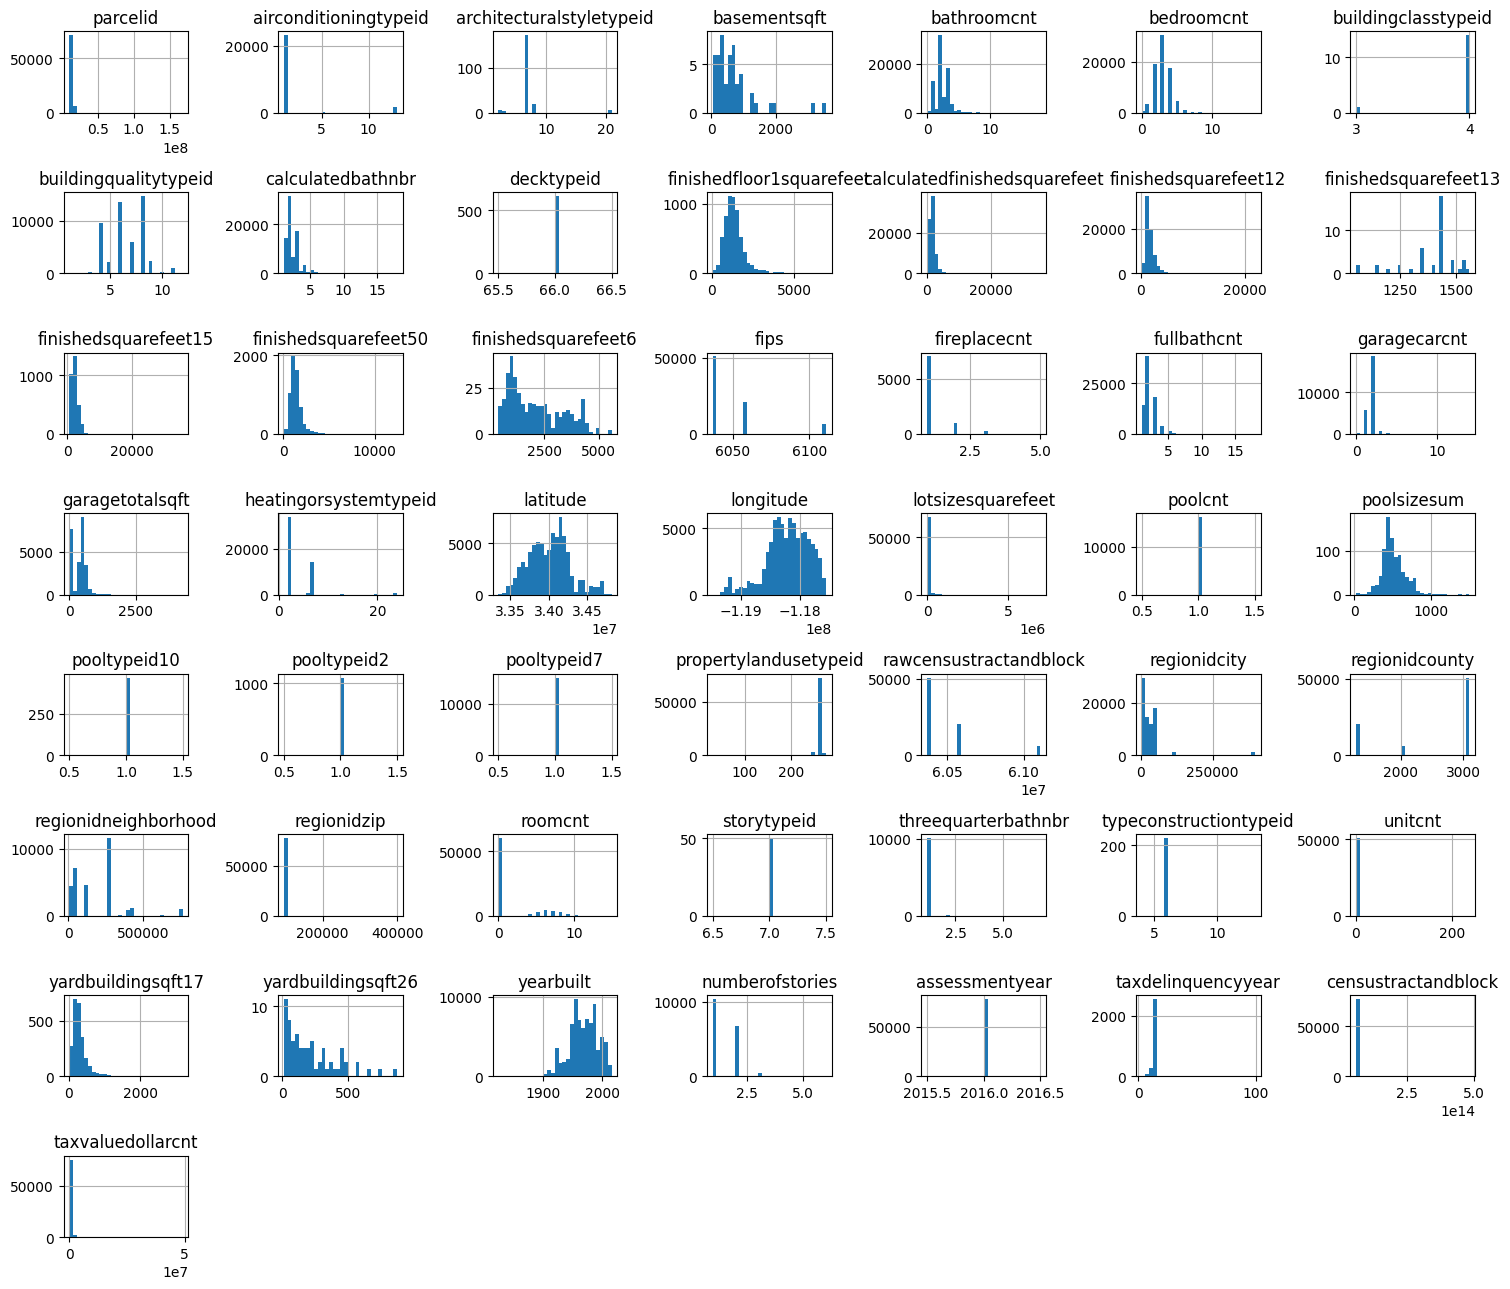

In [5]:
# Histogram of each feature in dataset
df.hist(figsize=(15, 13), bins=30)
plt.tight_layout()
plt.show()

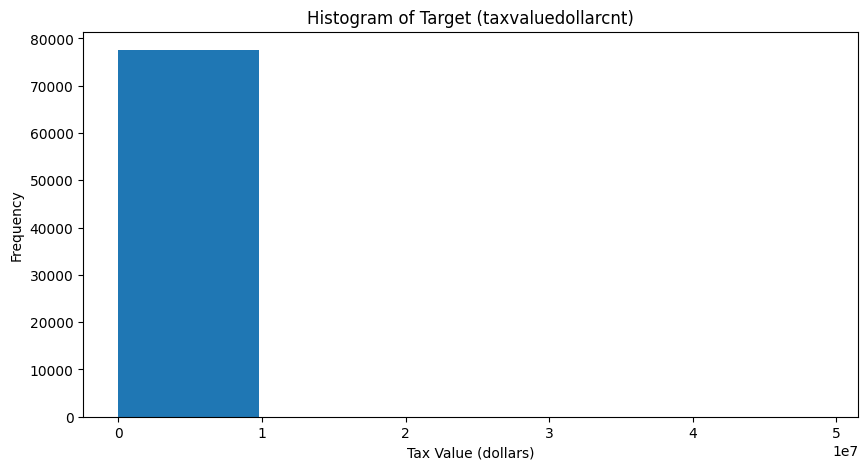

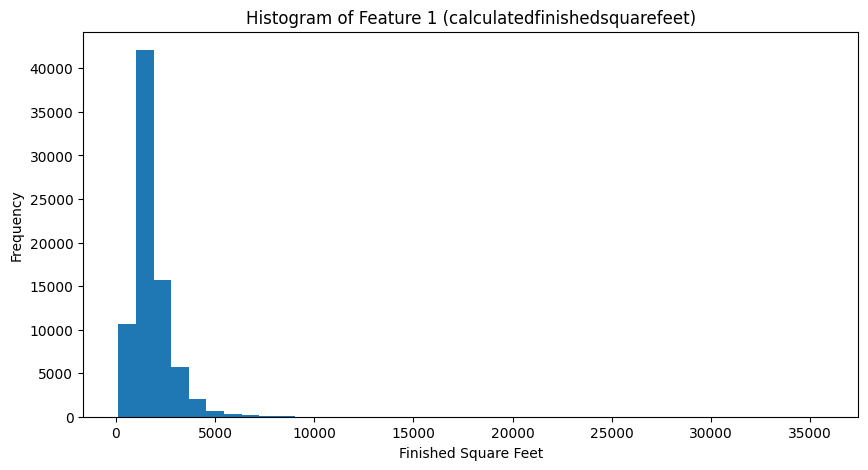

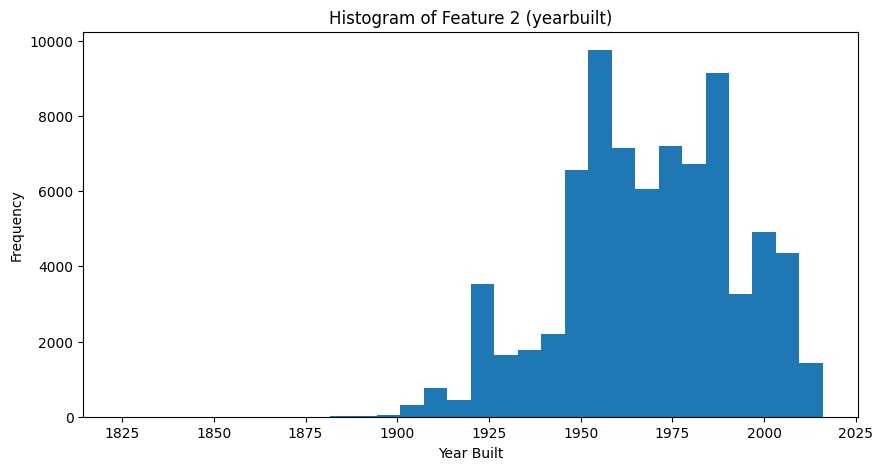

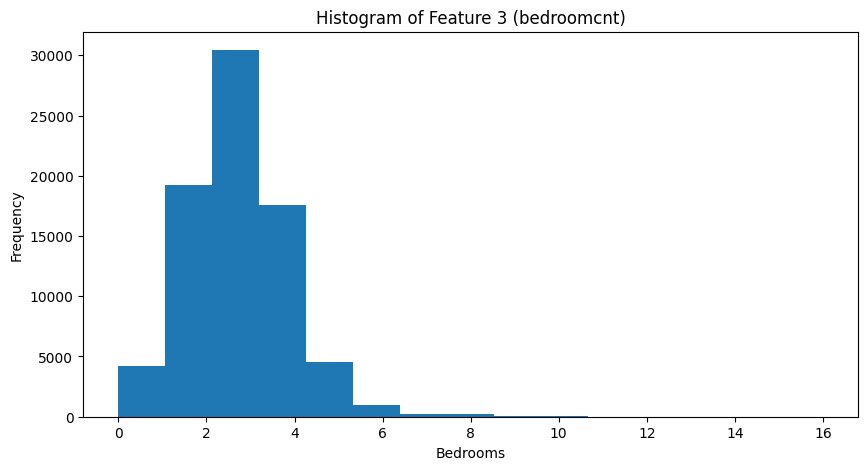

In [6]:
# Visualizations for target and 3 other features in dataset

# 1. Histogram of Target (taxvaluedollarcnt)
plt.figure(figsize=(10,5))
plt.hist(df['taxvaluedollarcnt'], bins=5)
plt.title('Histogram of Target (taxvaluedollarcnt)')
plt.xlabel('Tax Value (dollars)')
plt.ylabel('Frequency')
plt.show()

# 2. Histogram of Feature 1 (finishedfloor1squarefeet)
plt.figure(figsize=(10,5))
plt.hist(df['calculatedfinishedsquarefeet'], bins=40)
plt.title('Histogram of Feature 1 (calculatedfinishedsquarefeet)')
plt.xlabel('Finished Square Feet')
plt.ylabel('Frequency')
plt.show()

# 4. Histogram of Feature 2 (yearbuilt)
plt.figure(figsize=(10,5))
plt.hist(df['yearbuilt'], bins=30)
plt.title('Histogram of Feature 2 (yearbuilt)')
plt.xlabel('Year Built')
plt.ylabel('Frequency')
plt.show()


# 3. Histogram of Feature 3 (bedroomcnt)
plt.figure(figsize=(10,5))
plt.hist(df['bedroomcnt'], bins=15)
plt.title('Histogram of Feature 3 (bedroomcnt)')
plt.xlabel('Bedrooms')
plt.ylabel('Frequency')
plt.show()


#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


Following detailed examination of the features included in this dataset, we chose to take a further look at Feature 1 (calculatedfinishedsquarefeet), Feature 2 (yearbuilt), and Feature 3 (bedroomcnt).
Feature 1 (calculatedfinishedsquarefeet) shows an extremely right-skewed distribution as well as a strong right tail. This feature will be interesting to investigate as total square footage tends to positively impact home valuation and pricing.
Feature 2 (yearbuilt) shows a slighlty left-skewed distribution. This feature will be interesting to investigate as home values tend to change with age.
Feature 3 (bedroomcnt) also shows a right-skewed distibution. It will be interesting to investigate the relationships between bedroom count and total home square footage, bedroom count and bathroom count, and bedroom count and home tax value.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task!

In [7]:
def drop_unsuitable_feat6ures(df):
  df_dropped = df.copy()
  cols_to_drop = [
      # redundant typeID or high cardinality
      'parcelid', 'assessmentyear', 'propertyzoningdesc', 'propertycountylandusecode', 'censustractandblock', 'rawcensustractandblock', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip',

      # redundant square footage features
      'finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'finishedfloor1squarefeet',

      # redundant bathroom features
      'calculatedbathnbr', 'fullbathcnt', 'threequarterbathnbr',

      # redundant pool features
      'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7',

      # redundant fireplace features
      'fireplaceflag',

      # tax delinquency features
      'taxdelinquencyflag', 'taxdelinquencyyear',
      ]

  existing_cols_to_drop = [c for c in cols_to_drop if c in df_dropped.columns]
  df_dropped = df_dropped.drop(columns=existing_cols_to_drop)

  print(f"Dropped {len(existing_cols_to_drop)} features.")
  print(f"Original shape: {df.shape}")
  print(f"New shape: {df_dropped.shape}")

  return df_dropped

df_cleaned_A = drop_unsuitable_feat6ures(df)


Dropped 26 features.
Original shape: (77613, 55)
New shape: (77613, 29)


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop.


Many features were dropped due to being redundant, such as parcelid, assessmentyear, and those pertaining to finishedsquarefeet and pooltypeid among others. Some features were not as suitable for regression such as taxdelinquencyyear and taxdelinquencyflag which were dropped to prevent potential data leakage since they will likely not be relevant for property value prediction. The regionidneighborhood, regionidcity, regionidcounty, and regionidzip were dropped in favor of keeping latitude and longitude which may provide better spatial information for regression.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully.

In [8]:
def drop_high_null_features(df, threshold = 0.95):

  null_pct = df.isnull().mean()
  cols_to_drop = null_pct[null_pct > threshold].index.tolist()
  print(f"Dropping {len(cols_to_drop)} columns with >{int(threshold*100)}% missing values:")
  print(cols_to_drop)
  return df.drop(columns=cols_to_drop)
df_cleaned_B = drop_high_null_features(df_cleaned_A, threshold = 0.95)


Dropping 9 columns with >95% missing values:
['architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'hashottuborspa', 'storytypeid', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26']


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



We decided to drop features that have more than 95% missing values. Due to their extreme sparsity, keeping these features would not benefit the regression model as they provided little information and introduce noise. We imputed code to drop features that surpass the 95% threshold set.

### Part 3.C: Drop Problematic **samples**

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [9]:
def drop_problematic_samples(df, target_col='taxvaluedollarcnt', null_threshold=0.5, outlier_method='iqr'):

    df_clean = df.copy()
    initial_count = len(df_clean)

    # Drop rows with null values in the target
    null_target_count = df_clean[target_col].isnull().sum()
    df_clean = df_clean[df_clean[target_col].notnull()]
    print(f"Dropped {null_target_count} rows with null target values")

    # Drop rows with too many null values
    null_per_row = df_clean.isnull().mean(axis=1)
    high_null_count = (null_per_row > null_threshold).sum()
    df_clean = df_clean[null_per_row <= null_threshold]
    print(f"Dropped {high_null_count} rows with >{null_threshold*100}% null values")

    # Identify and drop outliers in target using IQR method
    if outlier_method == 'iqr':
        Q1 = df_clean[target_col].quantile(0.25)
        Q3 = df_clean[target_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_count = ((df_clean[target_col] < lower_bound) | (df_clean[target_col] > upper_bound)).sum()
        print(f"Identified {outlier_count} outliers in target (IQR method)")
        print(f"  Lower bound: ${lower_bound:,.0f}, Upper bound: ${upper_bound:,.0f}")

        # Drop extreme outliers (values outside 3*IQR)
        extreme_lower = Q1 - 3 * IQR
        extreme_upper = Q3 + 3 * IQR
        extreme_count = ((df_clean[target_col] < extreme_lower) | (df_clean[target_col] > extreme_upper)).sum()

        if extreme_count > 0:
            df_clean = df_clean[(df_clean[target_col] >= extreme_lower) & (df_clean[target_col] <= extreme_upper)]
            print(f"Dropped {extreme_count} extreme outliers (outside 3*IQR)")

    final_count = len(df_clean)
    total_dropped = initial_count - final_count
    print(f"\nTotal rows dropped: {total_dropped}")
    print(f"Original shape: ({initial_count}, {df.shape[1]})")
    print(f"Final shape: ({final_count}, {df.shape[1]})")

    return df_clean

df_cleaned_C = drop_problematic_samples(df_cleaned_B, target_col='taxvaluedollarcnt')


Dropped 35 rows with null target values
Dropped 185 rows with >50.0% null values
Identified 5140 outliers in target (IQR method)
  Lower bound: $-335,465, Upper bound: $1,110,943
Dropped 2318 extreme outliers (outside 3*IQR)

Total rows dropped: 2538
Original shape: (77613, 20)
Final shape: (75075, 20)


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


First we removed 35 rows with null values in the target variable, since they cannot be used for supervised regression training. Then we removed 185 rows with more than 50% of missing values across remaining features as they provide insufficient information for modeling. Lastly, we identified and removed 2,318 extreme outliers in the target variable using the 3xIQR method. Overall, roughly 3.3% of the data was removed to bring about a cleaner dataset for model training.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [10]:
def impute_remaining_missing_values(df):
    df_imputed = df.copy()

      # Special-case indicator-like columns
    if "poolcnt" in df_imputed.columns:
        df_imputed["poolcnt"] = df_imputed["poolcnt"].fillna(0).astype(int)

    # Split by dtype so each group can use the appropriate strategy
    numeric_cols = df_imputed.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df_imputed.select_dtypes(exclude=[np.number]).columns.tolist()

    missing_before = df_imputed.isnull().sum().sum()
    print(f"Total missing values before imputation: {missing_before}")

    # Median imputation for numeric features
    if numeric_cols:
        num_imputer = SimpleImputer(strategy='median')
        df_imputed[numeric_cols] = num_imputer.fit_transform(df_imputed[numeric_cols])

    # Mode imputation for categorical features
    if categorical_cols:
        for col in categorical_cols:
            if df_imputed[col].isnull().any():
                mode_values = df_imputed[col].mode(dropna=True)
                fill_value = mode_values.iloc[0] if not mode_values.empty else 'Unknown'
                df_imputed[col] = df_imputed[col].fillna(fill_value)

    missing_after = df_imputed.isnull().sum().sum()
    print(f"Total missing values after imputation: {missing_after}")

    if missing_after == 0:
        print("Imputation successful: no null values remain.")
    else:
        print("Warning: some null values still remain.")

    return df_imputed

# Apply imputation to Part 3.C output
df_cleaned_D = impute_remaining_missing_values(df_cleaned_C)

print(f"Shape after imputation: {df_cleaned_D.shape}")

Total missing values before imputation: 364260
Total missing values after imputation: 0
Imputation successful: no null values remain.
Shape after imputation: (75075, 20)


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


 For numeric features, we used median imputation because many of the features are not symmetrically distributed. If mean imputation was used it may inflate filled in values causing them to be less representative. The median is much less affected by outliers. After applying the respective imputation method the resulting dataset has no remaining values.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary.

In [11]:
categorical_features_cleaned = df_cleaned_D.select_dtypes(include=['object', 'category']).columns.tolist()
if categorical_features_cleaned:
    print(f"Categorical features in the cleaned dataset: {categorical_features_cleaned}")
else:
    print("No categorical features found in the cleaned dataset.")


No categorical features found in the cleaned dataset.


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project.

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well).
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments.

Text(0.5, 1.0, 'Correlation Matrix')

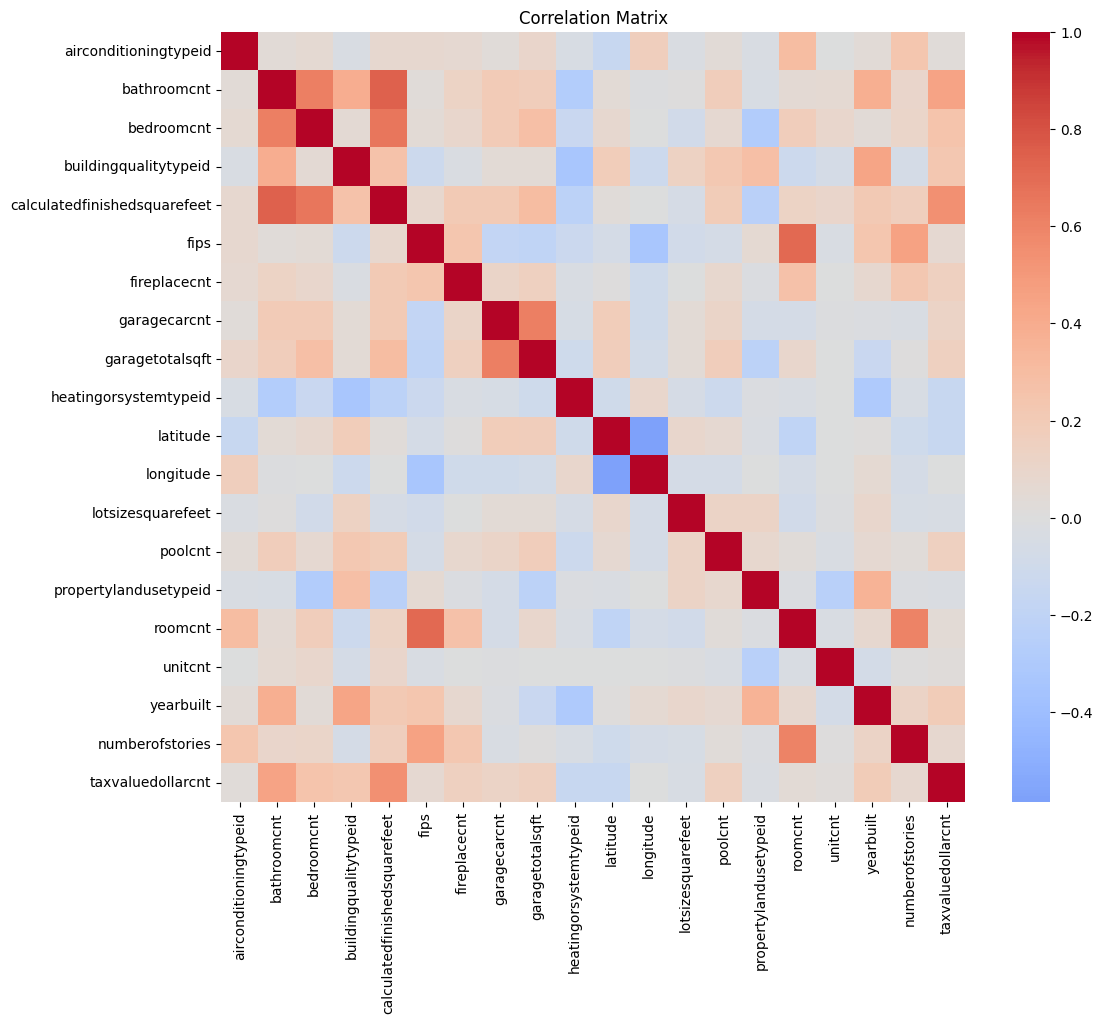

In [12]:
df_clean = df_cleaned_D

df_corr = df_clean.corr(numeric_only=True)


plt.figure(figsize=(12, 10))
sns.heatmap(df_corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")


In [14]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [15]:
base_path = "/content/drive/MyDrive/Colab Notebooks/603"

full_path = os.path.join(base_path, "df_clean.csv")

df_clean.to_csv(full_path, index=False)

Mounted at /content/drive


In [ ]:
## F scores

from sklearn.feature_selection import f_regression

X = ( df_clean
      .drop(columns=["taxvaluedollarcnt"])
      .select_dtypes(include="number")
)
y = df_clean["taxvaluedollarcnt"]


f_scores, p_values = f_regression(X, y)

f_df = pd.DataFrame({
    "feature": X.columns,
    "f_score": f_scores,
    "p_value": p_values
}).sort_values("f_score", ascending=False)

print(f_df)

                         feature       f_score        p_value
4   calculatedfinishedsquarefeet  30781.566005   0.000000e+00
1                    bathroomcnt  18463.901215   0.000000e+00
2                     bedroomcnt   5142.295283   0.000000e+00
3          buildingqualitytypeid   4132.460092   0.000000e+00
17                     yearbuilt   2952.384950   0.000000e+00
10                      latitude   1866.181277   0.000000e+00
6                   fireplacecnt   1713.518575   0.000000e+00
13                       poolcnt   1671.460641   0.000000e+00
8                garagetotalsqft   1669.841366   0.000000e+00
9          heatingorsystemtypeid   1629.757371   0.000000e+00
7                   garagecarcnt   1083.793352  5.333756e-236
18               numberofstories    414.443115   7.009408e-92
5                           fips    354.711645   6.075037e-79
15                       roomcnt    164.494779   1.291890e-37
12             lotsizesquarefeet    129.036024   7.045137e-30
0       

In [ ]:
## forward feature selection
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

X = df_clean.drop(columns=["taxvaluedollarcnt"])
y = df_clean["taxvaluedollarcnt"]


model= LinearRegression()
Forward_selector = SequentialFeatureSelector(model,
                                             n_features_to_select=10,
                                             direction='forward',
                                             scoring = "neg_mean_squared_error",
                                             cv=5,
                                             n_jobs=-1)
Forward_selector.fit(X, y)
selected_forward = X.columns[Forward_selector.get_support()]
print("Forward-selected features:")
print(selected_forward)


Forward-selected features:
Index(['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid',
       'calculatedfinishedsquarefeet', 'fireplacecnt', 'garagetotalsqft',
       'latitude', 'longitude', 'propertylandusetypeid', 'roomcnt'],
      dtype='object')


In [ ]:
## Backward feature seleciton

##define X and y
X = df_clean.drop(columns=["taxvaluedollarcnt"])
y = df_clean["taxvaluedollarcnt"]

model= LinearRegression()
Backward_selector = SequentialFeatureSelector(model,
                                             n_features_to_select=10,
                                             direction='backward',
                                             scoring = "neg_mean_squared_error",
                                             cv=5,
                                             n_jobs=-1)
Backward_selector.fit(X, y)
selected_backward = X.columns[Backward_selector.get_support()]
print("Forward-selected features:")
print(selected_backward)

Forward-selected features:
Index(['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid',
       'calculatedfinishedsquarefeet', 'fireplacecnt', 'garagetotalsqft',
       'latitude', 'longitude', 'propertylandusetypeid', 'roomcnt'],
      dtype='object')


#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships.
 How do the different methods for seeing relationships compare? Do they agree or disagree?



The correlation matrix and feature selection methods were broadly consistent. Features such as bathroomcnt, calculatedfinishedsquarefeet, roomcnt, and garagetotalsqft showed relatively strong relationships with taxvaluedollarcnt in the correlation matrix and were also selected by both forward and backward selection. In addition, the forward and backward methods produced identical feature subsets, suggesting that the most informative predictors are relatively stable and not highly sensitive to the selection procedure. Overall, the agreement across these methods increases confidence that these variables carry meaningful signal for the regression task, while also suggesting some redundancy among related housing-size and room-count features.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis.
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends.

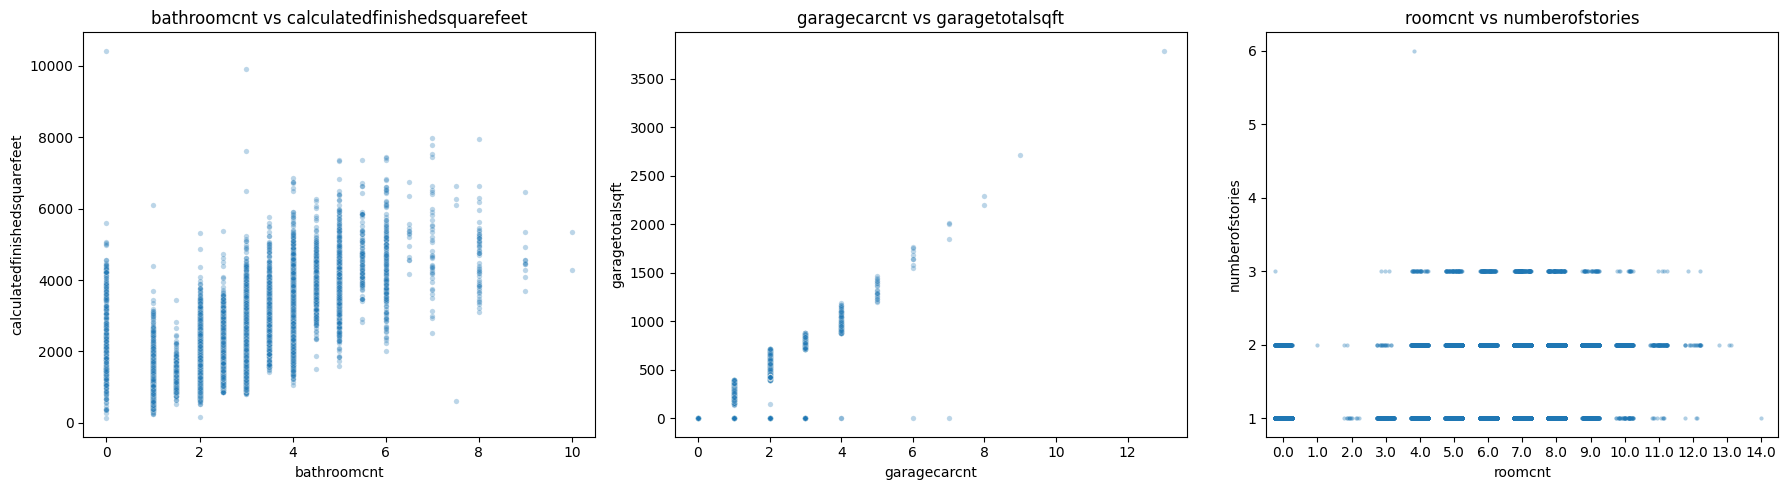

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=df_clean,
    x='bathroomcnt',
    y='calculatedfinishedsquarefeet',
    ax=axes[0],
    alpha=0.3,
    s=15
)
axes[0].set_title('bathroomcnt vs calculatedfinishedsquarefeet')

sns.scatterplot(
    data=df_clean,
    x='garagecarcnt',
    y='garagetotalsqft',
    ax=axes[1],
    alpha=0.3,
    s=15
)
axes[1].set_title('garagecarcnt vs garagetotalsqft')

sns.stripplot(
    data=df_clean,
    x='roomcnt',
    y='numberofstories',
    jitter=0.25,
    alpha=0.35,
    size=3,
    ax=axes[2]
)
axes[2].set_title('roomcnt vs numberofstories')

plt.tight_layout()


#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


The 2D plots showed several clear positive relationships between housing features. `bathroomcnt` and `calculatedfinishedsquarefeet` showed that larger homes generally have more bathrooms, although there was still noticeable spread. `garagecarcnt` and `garagetotalsqft` showed a strong positive relationship, which makes sense since larger garages usually hold more cars. `roomcnt` and `numberofstories` also showed a positive trend, though it appeared weaker and more variable than the other two pairs.


## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset.
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection).
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary.

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question.

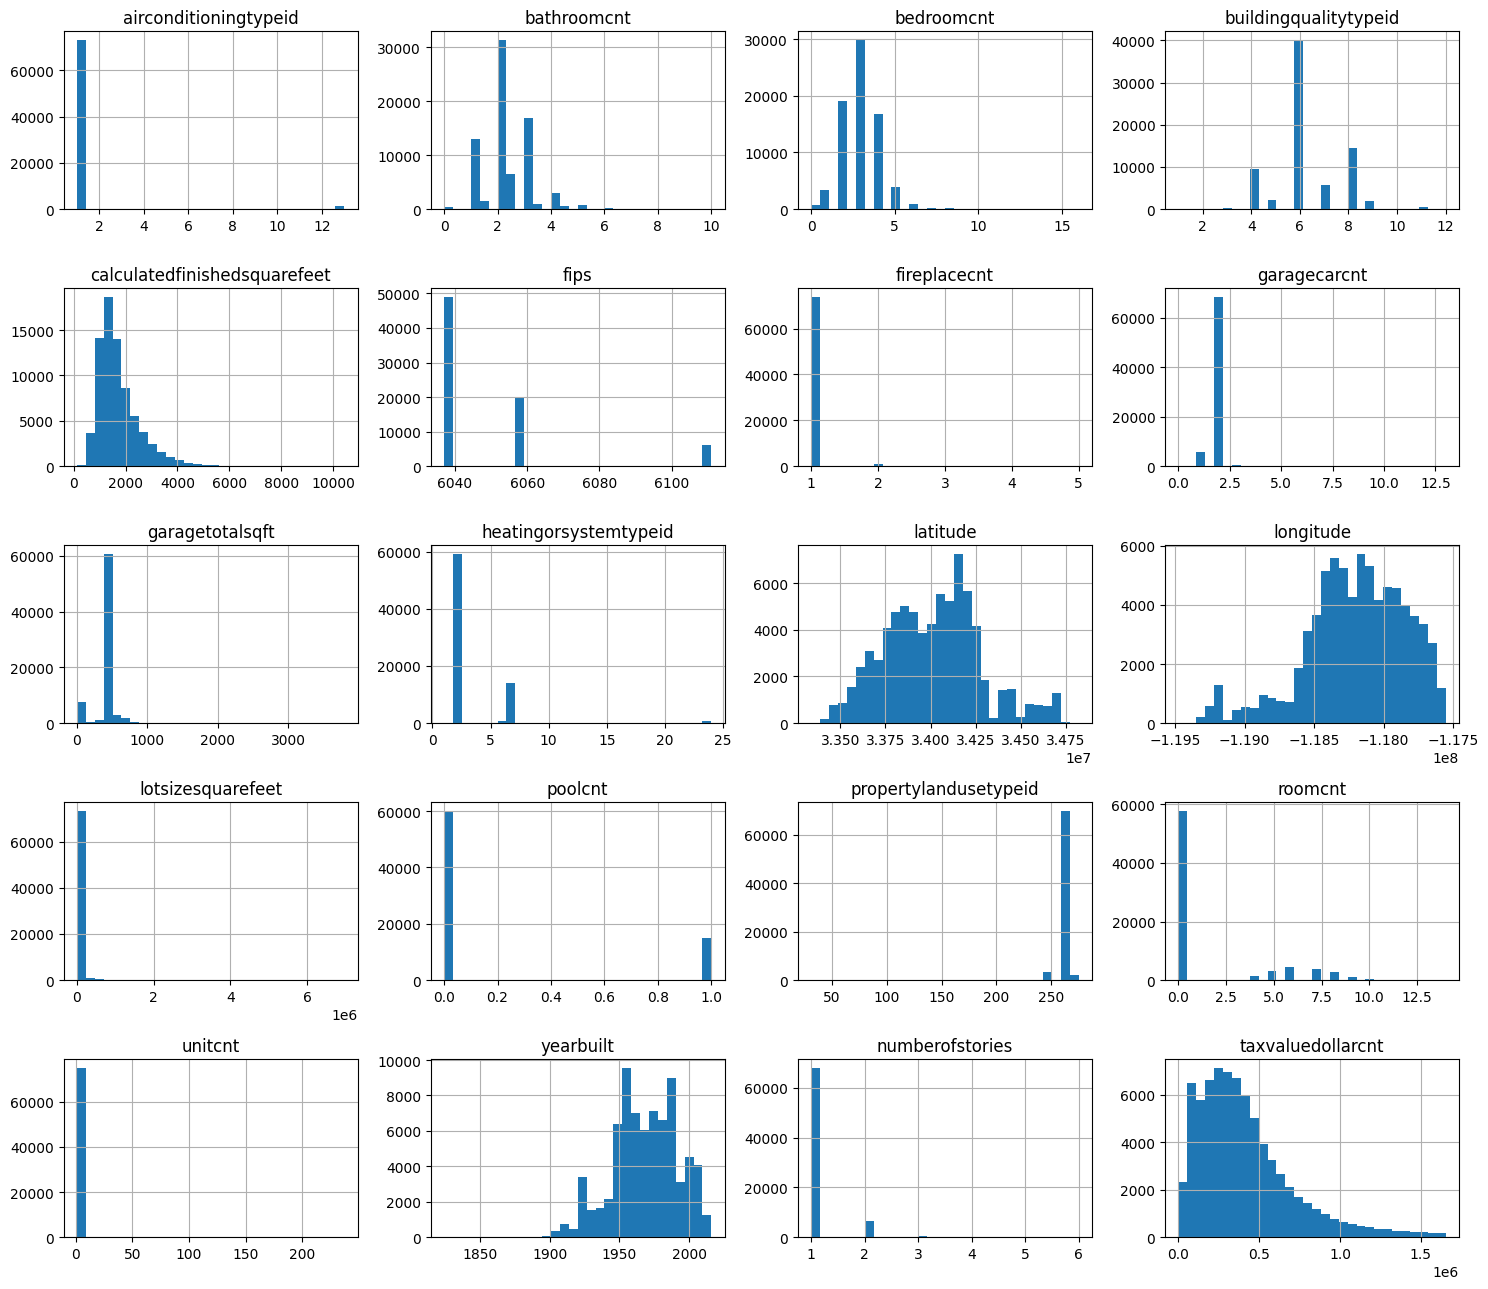

In [ ]:
### investigating cleaned data for potential features to engineer


df_clean.hist(figsize=(15, 13), bins=30)
plt.tight_layout()
plt.show()

In [ ]:
#### feature engineering - Feature 1 - Log transform lot square footage - right tail

def add_log_lot_size(df):
    df = df.copy()
    df["log_lotsizesquarefeet"] = np.log1p(df["lotsizesquarefeet"])
    return df

df_fe1 = add_log_lot_size(df_clean)



X_fe1 = df_fe1.select_dtypes(include="number").drop(columns=["taxvaluedollarcnt"])
# y doesn't change

f_scores, _ = f_regression(X_fe1, y)
f_df = pd.DataFrame({"feature": X_fe1.columns, "f_score": f_scores}).sort_values("f_score", ascending=False)
display(f_df)







,feature,f_score
4,calculatedfinishedsquarefeet,30781.566005
1,bathroomcnt,18463.901215
2,bedroomcnt,5142.295283
3,buildingqualitytypeid,4132.460092
17,yearbuilt,2952.384950
10,latitude,1866.181277
6,fireplacecnt,1713.518575
13,poolcnt,1671.460641
8,garagetotalsqft,1669.841366
9,heatingorsystemtypeid,1629.757371


In [ ]:
#### feature engineering - Feature 2- convert year built to age of home - more interpretable
def add_home_age(df, reference_year=2017):
    df = df.copy()
    df["home_age"] = reference_year - df["yearbuilt"] ###### dropped asses
    return df

df_fe2 = add_home_age(df_clean)

X_fe2= df_fe2.select_dtypes(include="number").drop(columns=["taxvaluedollarcnt"])
# y doesn't change


f_scores, _ = f_regression(X_fe2, y)
f_df = pd.DataFrame({"feature": X_fe2.columns, "f_score": f_scores}).sort_values("f_score", ascending=False)
display(f_df)



,feature,f_score
4,calculatedfinishedsquarefeet,30781.566005
1,bathroomcnt,18463.901215
2,bedroomcnt,5142.295283
3,buildingqualitytypeid,4132.460092
17,yearbuilt,2952.384950
19,home_age,2952.384950
10,latitude,1866.181277
6,fireplacecnt,1713.518575
13,poolcnt,1671.460641
8,garagetotalsqft,1669.841366


In [ ]:
#### feature engineering - Feature 3 - trying out merging features by computing a ratio


def add_bath_per_bedroom(df):
    df = df.copy()
    df["bath_per_bedroom"] = df["bathroomcnt"] / df["bedroomcnt"].replace(0, np.nan)
    df["bath_per_bedroom"] = df["bath_per_bedroom"].fillna(df["bathroomcnt"])
    return df

df_fe3 = add_bath_per_bedroom(df_clean)

X_fe3= df_fe3.select_dtypes(include="number").drop(columns=["taxvaluedollarcnt"])
# y doesn't change

f_scores, _ = f_regression(X_fe3, y)
f_df = pd.DataFrame({"feature": X_fe3.columns, "f_score": f_scores}).sort_values("f_score", ascending=False)

display(f_df)




,feature,f_score
4,calculatedfinishedsquarefeet,30781.566005
1,bathroomcnt,18463.901215
2,bedroomcnt,5142.295283
3,buildingqualitytypeid,4132.460092
17,yearbuilt,2952.384950
19,bath_per_bedroom,2581.114607
10,latitude,1866.181277
6,fireplacecnt,1713.518575
13,poolcnt,1671.460641
8,garagetotalsqft,1669.841366


#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed.


I tried three feature engineering ideas based on common patterns in housing data: a log transform of `lotsizesquarefeet`, converting `yearbuilt` into `home_age`, and creating a `bath_per_bedroom` ratio. I chose the log transform because `lotsizesquarefeet` was strongly right-skewed, so compressing the tail might expose a clearer relationship with the target. I converted `yearbuilt` into `home_age` because age is often more interpretable than raw construction year and may better reflect how older homes differ in value. I also created `bath_per_bedroom` because a ratio between bathrooms and bedrooms may capture layout or amenity quality better than either raw count alone. I compared each new feature using F-scores. The log-transformed lot size did not improve the score and looks less useful than the original feature. `home_age` ended up with almost the same F-score as `yearbuilt`, which makes sense since it contains nearly the same information, although it may still be easier to interpret later. The `bath_per_bedroom` ratio had a moderate F-score, but it was still weaker than `bathroomcnt` by itself. Overall, these transformations were sensible to test, but none of them clearly improved on the strongest original features in this dataset.


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

